In [17]:
#%pip install pandas==2.2.3
#%pip install git+https://github.com/pydata/pandas-datareader.git
#%pip install yfinance numpy matplotlib

In [18]:
import pandas as pd #Importamos pandas para el manejo de dataframes y series temporales
import numpy as np #Importamos numpy para el manejo de arrays y operaciones matemáticas
import matplotlib.pyplot as plt #Importamos matplotlib para la visualización de datos       
from sklearn.ensemble import RandomForestRegressor #Importamos RandomForestRegressor para la selección de variables y la construcción del modelo de machine learning
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit #Importamos GridSearchCV para la búsqueda de hiperparámetros y TimeSeriesSplit para la validación cruzada en series temporales
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer #Importamos mean_absolute_error, mean_squared_error y r2_score para la evaluación del rendimiento del modelo de machine learning
import joblib #Importamos joblib para guardar y cargar modelos de machine learning entrenados
from sklearn.preprocessing import QuantileTransformer #Importamos QuantileTransformer para la transformación de variables numéricas
from sklearn.isotonic import IsotonicRegression #Importamos IsotonicRegression para realizar regresión isotónica, que es una técnica de ajuste de curvas monotónicas

In [19]:
df = pd.read_csv('../../dataset_ml.csv') 
print(df.head())

#df.drop(columns=['Date'], inplace=True) #Eliminamos la columna 'Date' ya que no es una característica numérica y no aporta información relevante para el modelo. Además, eliminamos la columna 'target' ya que es la variable que queremos predecir.

   oro_return    precio  inflacion_usa  volatilidad_6m     lag_3  tipos_ecb  \
0    0.047631  0.320155       0.020352        0.088742 -0.083592        1.0   
1   -0.032475  0.337983       0.020263        0.081350  0.104730        1.0   
2    0.022960  0.358358       0.016885        0.079723 -0.086500        1.0   
3    0.038561  0.405100       0.017401        0.076144  0.021998        1.0   
4   -0.094313  0.386223       0.022926        0.078530  0.055686        1.0   

     eurusd  activo_return  desempleo  sp500_return  ...  inflacion_usa_lag1  \
0  1.259002       0.021998        5.7      0.050766  ...            0.020348   
1  1.245206       0.055686        5.7      0.017276  ...            0.020352   
2  1.253007       0.060284        5.6      0.012209  ...            0.020263   
3  1.231300       0.130434        5.8     -0.016359  ...            0.016885   
4  1.198294      -0.046598        5.6     -0.016791  ...            0.017401   

   inflacion_usa_lag3  inflacion_usa_lag6   

In [20]:
X = df.drop(columns=['target']) #Separamos las características (X) de la variable objetivo (Y) para preparar los datos para el entrenamiento del modelo de machine learning.
Y = df['target']

In [21]:
def division_conjuntos(dataframe, tr_size=0.8, vl_size=0.1, ts_size=0.1 ):
    '''Función para dividir un dataframe en conjuntos de entrenamiento, validación y prueba.
    Parámetros:
    dataframe: DataFrame a dividir
    tr_size: Proporción de datos para el conjunto de entrenamiento (default=0.8)
    vl_size: Proporción de datos para el conjunto de validación (default=0.1)
    ts_size: Proporción de datos para el conjunto de prueba (default=0.1)
    Retorna:
    train: DataFrame de entrenamiento
    val: DataFrame de validación
    test: DataFrame de prueba
    '''
    N = dataframe.shape[0] # Número total de datos
    Ntrain = int(tr_size*N)  # Número de datos de entrenamiento
    Nval = int(vl_size*N)    # Número de datos de validación
    Ntst = int(ts_size*N)    # Número de datos de prueba

    # Realizar partición
    train = dataframe[0:Ntrain] # Conjunto de entrenamiento
    val = dataframe[Ntrain:Ntrain+Nval] # Conjunto de validación
    test = dataframe[Ntrain+Nval:] # Conjunto de prueba

    return train, val, test

# Prueba de la función
tr, vl, ts = division_conjuntos(df) # Dividimos el dataframe en conjuntos de entrenamiento, validación y prueba utilizando la función division_conjuntos.

X_train = tr.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de entrenamiento, eliminando la columna 'target' que es la variable que queremos predecir.
y_train = tr['target']

X_val = vl.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de validación, eliminando la columna 'target' que es la variable que queremos predecir.
y_val = vl['target']

X_test = ts.drop(columns=['target']) # Separamos las características (X) de la variable objetivo (Y) para el conjunto de prueba, eliminando la columna 'target' que es la variable que queremos predecir.
y_test = ts['target']

print(f'Entrenamiento: {X_train.shape}')
print(f'Validación: {X_val.shape}')
print(f'Prueba: {X_test.shape}')

Entrenamiento: (212, 26)
Validación: (26, 26)
Prueba: (27, 26)


In [22]:
def directional_accuracy(y_true, y_pred):
    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)
    valid = true_dir != 0
    if valid.sum() == 0:
        return 0
    return np.mean(true_dir[valid] == pred_dir[valid])

# Creamos el scorer para GridSearch
da_scorer = make_scorer(directional_accuracy, greater_is_better=True)

In [23]:

param_grid_rf = {
    'n_estimators': [100, 200, 300], #Número de árboles en el bosque
    'max_depth': [10, 15, 20, None], #Profundidad máxima de los árboles.
    'min_samples_split': [2, 5, 10], #Número mínimo de muestras requeridas para dividir un nodo interno.
    'min_samples_leaf': [1, 2 ,4], #Número mínimo de muestras requeridas para estar en un nodo hoja.
    'max_features': ['sqrt', 'log2', None] #Número de características a considerar para encontrar la mejor división en cada nodo.
} #Definimos una cuadrícula de hiperparámetros para el modelo de Random Forest,

ts_cv = TimeSeriesSplit(n_splits=4) #Definimos una estrategia de validación cruzada para series temporales utilizando TimeSeriesSplit, que divide los datos en conjuntos de entrenamiento y validación respetando el orden temporal de los datos.

# Inicializar el modelo
rf = RandomForestRegressor(random_state=42, n_jobs=-1) #Inicializamos el modelo de Random Forest Regressor con un estado aleatorio fijo para reproducibilidad y utilizando todos los núcleos disponibles para acelerar el entrenamiento.

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=ts_cv,
    scoring=da_scorer,
    verbose=1,
    n_jobs=-1
)  # Configuramos la búsqueda de hiperparámetros utilizando GridSearchCV, especificando el modelo, la cuadrícula de hiperparámetros, la estrategia de validación cruzada, la métrica de evaluación, y habilitando la salida detallada y el uso de múltiples núcleos para acelerar el proceso.

# Ajustar la búsqueda
grid_search_rf.fit(X_train, y_train) #Ejecutamos la búsqueda de hiperparámetros ajustando el modelo a los datos de entrenamiento utilizando la configuración definida en GridSearchCV.


print(f"Mejores hiperparámetros: {grid_search_rf.best_params_}")
print(f"Mejor MAE: {-grid_search_rf.best_score_:.4f}")

Fitting 4 folds for each of 324 candidates, totalling 1296 fits
Mejores hiperparámetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Mejor MAE: -0.6071


In [24]:
best_rf = RandomForestRegressor(**grid_search_rf.best_params_, random_state=42, n_jobs=-1) #Creamos un nuevo modelo de Random Forest Regressor utilizando los mejores hiperparámetros encontrados en la búsqueda.
best_rf.fit(X_train, y_train) #Entrenamos el modelo de Random Forest Regressor con los mejores hiperparámetros utilizando los datos de entrenamiento.

y_pred_val_raw = best_rf.predict(X_val) #Realizamos predicciones utilizando el modelo entrenado en el conjunto de validación para evaluar su rendimiento antes de probarlo en el conjunto de prueba.

calibrator_rf = IsotonicRegression(out_of_bounds='clip')
calibrator_rf.fit(y_pred_val_raw, y_val)

# Calibrar predicciones de test
y_pred_test_raw = best_rf.predict(X_test)
y_pred_test_calibrated = calibrator_rf.predict(y_pred_test_raw)

# Ver efecto de la calibración
print("\n=== EFECTO DE LA CALIBRACIÓN (RF) ===")
print(f"Media real (test): {y_test.mean():.4f}")
print(f"Media predicción original: {y_pred_test_raw.mean():.4f}")
print(f"Media predicción calibrada: {y_pred_test_calibrated.mean():.4f}")

r2_original = r2_score(y_test, y_pred_test_raw)
r2_calibrado = r2_score(y_test, y_pred_test_calibrated)

print(f"\nR² original: {r2_original:.4f}")
print(f"R² calibrado: {r2_calibrado:.4f}")

# Decidir cuál usar
if r2_calibrado > r2_original:
    print("\n✅ Usando predicciones CALIBRADAS (mejor R²)")
    y_pred_test = y_pred_test_calibrated
else:
    print("\n⚠️ Usando predicciones ORIGINALES")
    y_pred_test = y_pred_test_raw

y_pred_val = calibrator_rf.predict(y_pred_val_raw) if r2_calibrado > r2_original else y_pred_val_raw

# Métricas de validación
mae_val = mean_absolute_error(y_val, y_pred_val) #Calculamos el error absoluto medio (MAE) entre las predicciones del modelo y los valores reales en el conjunto de validación para evaluar la precisión del modelo.
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val)) #Calculamos la raíz del error cuadrático medio (RMSE) entre las predicciones del modelo y los valores reales en el conjunto de validación para evaluar la precisión del modelo, penalizando más los errores grandes.
r2_val = r2_score(y_val, y_pred_val)
da_val = directional_accuracy(y_val, y_pred_val)

print(f"MAE: {mae_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")
print(f"R²: {r2_val:.4f}")
print(f"Directional Accuracy: {da_val:.4f}")


=== EFECTO DE LA CALIBRACIÓN (RF) ===
Media real (test): 0.0186
Media predicción original: 0.0173
Media predicción calibrada: 0.0246

R² original: -0.1277
R² calibrado: -0.0107

✅ Usando predicciones CALIBRADAS (mejor R²)
MAE: 0.0707
RMSE: 0.0811
R²: 0.0287
Directional Accuracy: 0.5385


MAE: 0.0741
RMSE: 0.0888
R²: -0.1660
Directional Accuracy: 0.4615

In [25]:
# Evaluación en el conjunto de prueba

y_pred_test = best_rf.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)
da_test = directional_accuracy(y_test, y_pred_test)

print(f"MAE: {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²: {r2_test:.4f}")
print(f"Directional Accuracy: {da_test:.4f}")

MAE: 0.0509
RMSE: 0.0615
R²: -0.1277
Directional Accuracy: 0.5926


MAE: 0.0479
RMSE: 0.0578
R²: 0.0037
Directional Accuracy: 0.5926

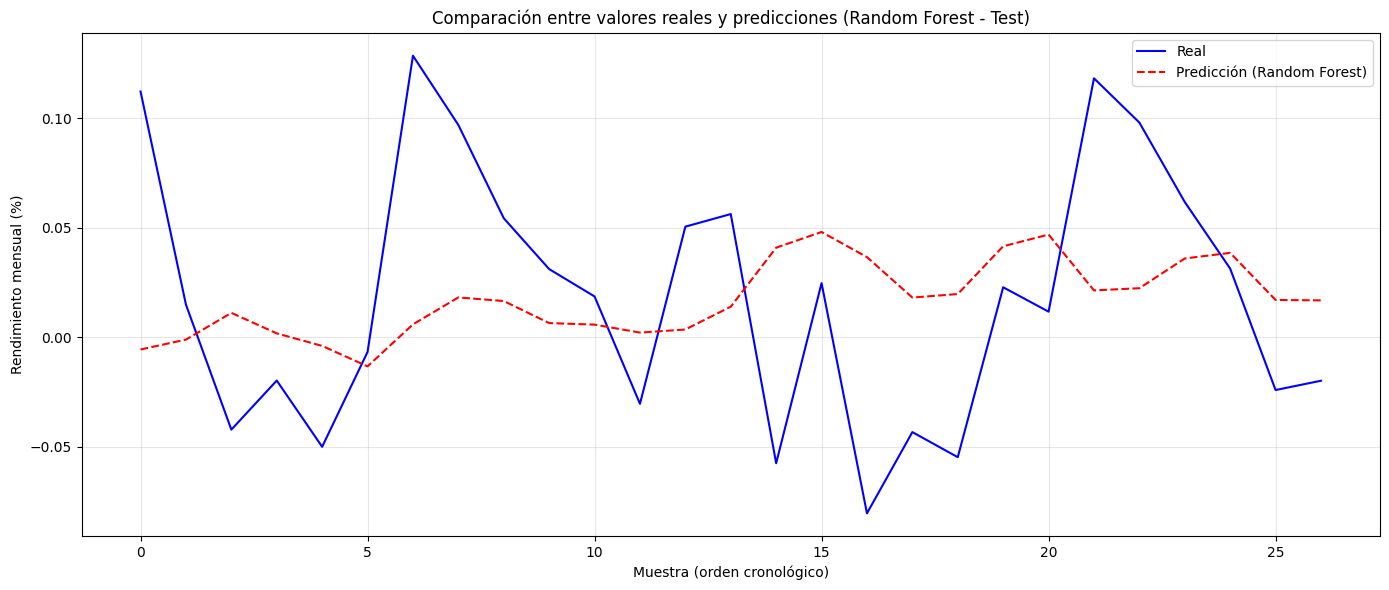

In [26]:
plt.figure(figsize=(14, 6))

# Ordenar por índice (asegurar orden cronológico)
indices = range(len(y_test))

plt.plot(indices, y_test.values, label='Real', color='blue', linewidth=1.5)
plt.plot(indices, y_pred_test, label='Predicción (Random Forest)', color='red', linestyle='--', linewidth=1.5)

plt.title('Comparación entre valores reales y predicciones (Random Forest - Test)')
plt.xlabel('Muestra (orden cronológico)')
plt.ylabel('Rendimiento mensual (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [27]:
def backtesting_rf(dataframe, window_train=180, test_size=12, step=12, best_params=None):
    """
    Realiza backtesting con ventana deslizante para Random Forest.
    
    Parámetros:
    -----------
    dataframe : DataFrame
        Dataset completo ordenado cronológicamente
    window_train : int
        Tamaño de la ventana de entrenamiento (meses)
    test_size : int
        Tamaño de la ventana de prueba (meses)
    step : int
        Número de meses que se desplaza la ventana en cada iteración
    best_params : dict
        Mejores hiperparámetros encontrados en la búsqueda previa
        
    Retorna:
    --------
    resultados : DataFrame
        DataFrame con las métricas de cada iteración
    media_metricas : dict
        Diccionario con las métricas promedio
    """
    
    resultados = []
    
    if best_params is None:
        best_params = {
            'n_estimators': 200,
            'max_depth': 15,
            'min_samples_split': 5,
            'min_samples_leaf': 2,
            'max_features': 'sqrt',
            'random_state': 42,
            'n_jobs': -1
        } # Si no se proporcionan mejores hiperparámetros, se usan valores por defecto
    
    # Calcular número total de iteraciones
    n_iterations = (len(dataframe) - window_train - test_size) // step + 1 # Calculamos el número total de iteraciones que se realizarán en el backtesting, teniendo en cuenta el tamaño de la ventana de entrenamiento, el tamaño de la ventana de prueba y el paso de desplazamiento.
    
    for i, start in enumerate(range(0, len(dataframe) - window_train - test_size, step)): # Iteramos sobre el rango de índices para crear las ventanas de entrenamiento y prueba, desplazando la ventana en cada iteración según el paso definido.
        
        train_end = start + window_train
        test_end = train_end + test_size
        
        # Obtenemos los datos de entrenamiento y prueba
        train = dataframe.iloc[start:train_end]
        test = dataframe.iloc[train_end:test_end]
        
        # Separamos características (X) y variable objetivo (y)
        X_train = train.drop(columns=['target'])
        y_train = train['target']
        
        X_test = test.drop(columns=['target'])
        y_test = test['target']
        
        # Creamos y entrenamos el modelo con los mejores hiperparámetros
        rf = RandomForestRegressor(**best_params)
        rf.fit(X_train, y_train)
        
        # Realizamos predicciones
        y_pred = rf.predict(X_test)
        
        # Calculamos métricas
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        if isinstance(dataframe.index, pd.RangeIndex): # Información de las fechas (si el índice es numérico, mostrar rangos)
            periodo_train = f"[{start}:{train_end-1}]"
            periodo_test = f"[{train_end}:{test_end-1}]"
        else: # Información de las fechas (si el índice es de tipo fecha, mostrar rangos de fechas)
            periodo_train = f"{train.index[0]} - {train.index[-1]}"
            periodo_test = f"{test.index[0]} - {test.index[-1]}"
        
        resultados.append({
            'iteracion': i + 1,
            'train_inicio': start,
            'train_fin': train_end - 1,
            'test_inicio': train_end,
            'test_fin': test_end - 1,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Da': directional_accuracy(y_test, y_pred)
        }) # Guardamos los resultados de cada iteración en una lista de diccionarios, donde cada diccionario contiene la información de la iteración, los índices de las ventanas de entrenamiento y prueba, y las métricas calculadas (MAE, RMSE, R²).
            
    df_resultados = pd.DataFrame(resultados) # Convertimos la lista de resultados a un DataFrame para facilitar el análisis y la visualización de las métricas obtenidas en cada iteración del backtesting.
    
    media_metricas = {
        'MAE_mean': df_resultados['MAE'].mean(),
        'MAE_std': df_resultados['MAE'].std(),
        'RMSE_mean': df_resultados['RMSE'].mean(),
        'RMSE_std': df_resultados['RMSE'].std(),
        'R2_mean': df_resultados['R2'].mean(),
        'R2_std': df_resultados['R2'].std(),
        'Da_mean': df_resultados['Da'].mean(),
        'Da_std': df_resultados['Da'].std()    
    } # Calculamos las métricas promedio y su desviación estándar para cada métrica (MAE, RMSE, R²) a partir de los resultados obtenidos en cada iteración del backtesting.
    
    
    print(f"MAE medio: {media_metricas['MAE_mean']:.4f} (±{media_metricas['MAE_std']:.4f})")
    print(f"RMSE medio: {media_metricas['RMSE_mean']:.4f} (±{media_metricas['RMSE_std']:.4f})")
    print(f"R² medio: {media_metricas['R2_mean']:.4f} (±{media_metricas['R2_std']:.4f})")
    print(f"Directional Accuracy media: {media_metricas['Da_mean']:.4f} (±{media_metricas['Da_std']:.4f})")
    
    return df_resultados, media_metricas

In [28]:
best_params_rf = grid_search_rf.best_params_
best_params_rf['random_state'] = 42
best_params_rf['n_jobs'] = -1

# Ejecutamos backtesting
resultados_backtest, metricas_backtest = backtesting_rf(
    dataframe=df,
    window_train=200,  # 200 meses de entrenamiento (~16.7 años)
    test_size=24,      # 24 meses de prueba (~2 años)
    step=12,           # Desplazar la ventana 12 meses cada iteración
    best_params=best_params_rf
)

MAE medio: 0.0725 (±0.0184)
RMSE medio: 0.0890 (±0.0236)
R² medio: -0.4272 (±0.4326)
Directional Accuracy media: 0.4896 (±0.0399)


MAE medio: 0.0677 (±0.0118)
RMSE medio: 0.0812 (±0.0137)
R² medio: -0.1879 (±0.1062)
Directional Accuracy media: 0.4792 (±0.0722)


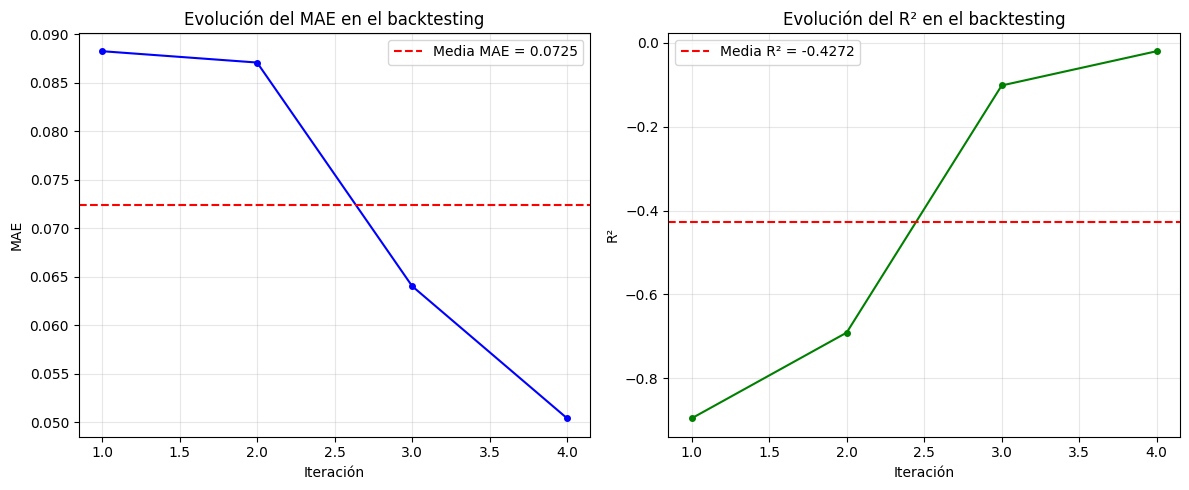

In [29]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(resultados_backtest['iteracion'], resultados_backtest['MAE'], 'o-', color='blue', markersize=4)
plt.axhline(y=metricas_backtest['MAE_mean'], color='red', linestyle='--', label=f'Media MAE = {metricas_backtest["MAE_mean"]:.4f}')
plt.xlabel('Iteración')
plt.ylabel('MAE')
plt.title('Evolución del MAE en el backtesting')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(resultados_backtest['iteracion'], resultados_backtest['R2'], 'o-', color='green', markersize=4)
plt.axhline(y=metricas_backtest['R2_mean'], color='red', linestyle='--', label=f'Media R² = {metricas_backtest["R2_mean"]:.4f}')
plt.xlabel('Iteración')
plt.ylabel('R²')
plt.title('Evolución del R² en el backtesting')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
